In [1]:
import yaml

# Load calibration.
camera_calibration = yaml.load(open("calibration_2024-10-25.yml"), Loader=yaml.CLoader)

In [2]:
import numpy as np
import cv2

def depth_at_ground_intersection(camera_name, camera_point):
    """
    Gets the depth at which a particular ray from the camera intersects
    the ground plane. It assumes that the world frame has its origin
    on the ground, which should be valid for the standard calibration
    workflow. (The extrinsics are calculated based on the assumption
    that the board is sitting on the ground. )
    
    Args:
        camera_name: The name of the camera.
        camera_point: The origin of the ray in camera coordinates.
    """
    side_to_ground_transform = get_transform_to_ground_frame(camera_name)
    transform_z_row = side_to_ground_transform[2]
    coefficients = [-camera_point[0], -camera_point[1], 0, -1]
    return np.dot(coefficients, transform_z_row) / transform_z_row[2]

def get_transform_to_ground_frame(camera_name):
    """
    Computes the transformation from the specified camera frame to a frame
    that is directly underneath it resting on the ground.
    """
    camera_data = camera_calibration[camera_name]
    camera_extrinsics = np.array(camera_data["extrinsics"]).reshape((4, 4))
    main_camera_data = camera_calibration["camera5"]
    main_camera_extrinsics = np.array(main_camera_data["extrinsics"]).reshape((4, 4))
    
    side_to_main = camera_extrinsics @ np.linalg.inv(main_camera_extrinsics)
    
    # Add the height offset to take us to the ground.
    main_camera_height = main_camera_extrinsics[2, 3]
    main_to_ground = np.eye(4)
    main_to_ground[2, 3] = -main_camera_height
    side_to_ground = main_to_ground @ side_to_main
    
    return side_to_ground

def get_points_for_camera(camera_name):
    """
    Projects the corners of the camera frame to the ground plane.
    """
    camera_data = camera_calibration[camera_name]
    intrinsics = np.array(camera_data["intrinsics"]).reshape((3, 3))
    extrinsics = np.array(camera_data["extrinsics"]).reshape((4, 4))
    distortion = np.array(camera_data["distortion"])
    resolution = np.array(camera_data["resolution"])
    
    # Start with the corner points in pixel coordinates.
    corners = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]]) * resolution
    
    # Convert to camera coordinates.
    camera_corners = cv2.undistortPoints(corners, intrinsics, distortion).squeeze()
    camera_corners_ground = np.zeros((4, 4))
    
    for i, point in enumerate(camera_corners):
        # Find the depth at which it intersects with the ground frame.
        camera_homo_point = np.array([0.0, 0.0, 0.0, 1.0])
        camera_homo_point[:2] = point
        camera_homo_point[2] = depth_at_ground_intersection(camera_name, point)
        
        # Convert to the ground frame.
        camera_corners_ground[i] = get_transform_to_ground_frame(camera_name) @ camera_homo_point
    
    
    return camera_corners_ground[:, :2]
    

In [3]:
from itertools import combinations
from shapely.geometry import Polygon
from shapely.set_operations import intersection

camera_ground_points = {}
for i in range(6):
    camera_ground_points[i] = get_points_for_camera(f"camera{i}")
    
camera_overlaps = {}
    
# Figure out the overlap between each pair for cameras.
for (camera1_id, camera1_points), (camera2_id, camera2_points) in combinations(camera_ground_points.items(), 2):
    camera1_poly = Polygon(camera1_points)
    camera2_poly = Polygon(camera2_points)
    
    # Find overlapping region.
    overlap = intersection(camera1_poly, camera2_poly)
    
    camera_overlaps[(camera1_id, camera2_id)] = overlap.area

In [4]:
import pickle

# Save it to a file.
pickle.dump(camera_overlaps, open("camera_overlaps_real.pkl", "wb"))

camera_overlaps


{
    (0, 1): 0.8463934787303864,
    (0, 2): 0.9762630778464947,
    (0, 3): 1.5461951278641577,
    (0, 4): 1.328189341047105,
    (0, 5): 1.2807521067821486,
    (1, 2): 0.4016920405011894,
    (1, 3): 0.5353152272169552,
    (1, 4): 0.5644634251362253,
    (1, 5): 0.5342865048254816,
    (2, 3): 1.1409816164629296,
    (2, 4): 0.8437300821646029,
    (2, 5): 1.0767738400315459,
    (3, 4): 1.3079461450886833,
    (3, 5): 1.578388752796441,
    (4, 5): 1.172735567482358
}

In [5]:
# Replace the camera views with human-friendly numbering.
_VIEW_MAP = {4: 1, 2: 2, 0: 3, 5: 4, 1: 5, 3: 6}

# Plot the camera polygons.
camera_polys = {}
for camera_id, camera_points in camera_ground_points.items():
    camera_polys[_VIEW_MAP[camera_id]] = Polygon(camera_points)

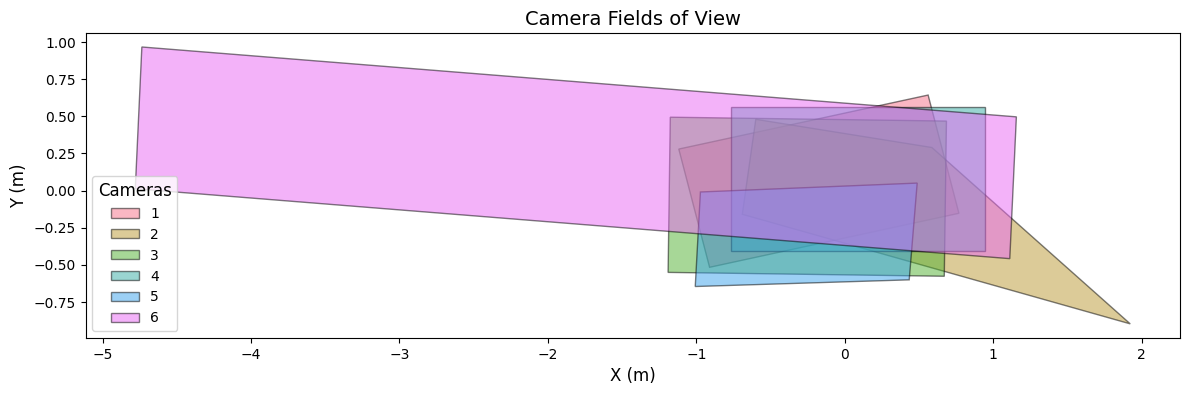

In [8]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from matplotlib.patches import Polygon as MplPolygon, Patch
from matplotlib.collections import PatchCollection
import seaborn as sns

def plot_polygons_with_labels(polygons, alpha=0.5, palette="tab10", figsize=(10, 8)):
    # Set up the figure and axes with the specified figure size
    fig, ax = plt.subplots(figsize=figsize)
    
    # Use Seaborn color palette
    colors = sns.color_palette(palette, n_colors=len(polygons))
    
    patches = []
    legend_handles = []  # To store legend handles
    
    # Make sure the polygons show up in a logical order in the legend.
    sorted_polys = sorted(polygons.items(), key=lambda p: p[0])
    
    # Loop through the dictionary and add polygons to the plot
    for idx, (key, polygon) in enumerate(sorted_polys):
        # Convert Shapely polygon to a Matplotlib-compatible polygon
        coords = list(polygon.exterior.coords)
        poly_patch = MplPolygon(coords, closed=True, facecolor=colors[idx], edgecolor="black", alpha=alpha, label=key)
        patches.append(poly_patch)
        ax.add_patch(poly_patch)
        
        # # Add a label at the centroid of the polygon
        # centroid = polygon.centroid
        # ax.text(
        #     centroid.x, centroid.y, key,
        #     fontsize=10, ha="center", va="center",
        #     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        # )
        
        # Add to legend handles
        legend_handles.append(Patch(facecolor=colors[idx], edgecolor="black", alpha=alpha, label=key))
    
    # Set axis limits and labels
    ax.autoscale()
    ax.set_aspect("equal")
    plt.xlabel("X (m)", fontsize=12)
    plt.ylabel("Y (m)", fontsize=12)
    plt.title("Camera Fields of View", fontsize=14)
    
    # Add the legend
    ax.legend(handles=legend_handles, loc="lower left", title="Cameras", fontsize=10, title_fontsize=12)
    
    plt.tight_layout()
    # Show the plot
    plt.show()


# Call the function with your `camera_polys` dictionary
plot_polygons_with_labels(camera_polys, palette="husl", figsize=(12, 10))